In [22]:
!git clone https://github.com/Alexandre-Reyob/option-pricing-models.git
import sys
sys.path.append('option-pricing-models')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.black_scholes import BlackScholes
from src.engine.monte_carlo import generate_gbm_paths, price_american_mc

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Setup complete!")

fatal: destination path 'option-pricing-models' already exists and is not an empty directory.
Setup complete!


In [23]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20

n_paths = 200000
n_steps = 252
dt = T / n_steps

np.random.seed(42)

print(f"Parameters: S0={S0}, K={K}, T={T}, r={r}, sigma={sigma}")
print(f"MC settings: {n_paths} paths, {n_steps} steps")

Parameters: S0=100, K=100, T=1.0, r=0.05, sigma=0.2
MC settings: 200000 paths, 252 steps


In [24]:
paths = generate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=42)

american_put = price_american_mc(paths, K, r, dt, 'put')
european_put = BlackScholes(S0, K, T, r, sigma).price('put')

print(f"American put (LSM): {american_put:.4f}")
print(f"European put: {european_put:.4f}")
print(f"Early exercise premium: {american_put - european_put:.4f}")

American put (LSM): 6.2396
European put: 5.5735
Early exercise premium: 0.6661


In [25]:
# Call américain sans dividende
# Théorie : un call américain sur une action sans dividende ne s'exerce jamais avant maturité
# Donc son prix est égal à celui du call européen.

european_call = BlackScholes(S0, K, T, r, sigma).price('call')
american_call = european_call

print(f"European call (Black-Scholes): {european_call:.4f}")
print(f"American call (theoretical): {american_call:.4f}")
print()
print("Note: For a non-dividend-paying stock, early exercise of an American call is never optimal.")
print("The American call price therefore equals the European call price by no-arbitrage.")

European call (Black-Scholes): 10.4506
American call (theoretical): 10.4506

Note: For a non-dividend-paying stock, early exercise of an American call is never optimal.
The American call price therefore equals the European call price by no-arbitrage.


In [26]:
# Vérification numérique : le prix LSM doit converger vers la valeur théorique
american_call_mc = price_american_mc(paths, K, r, dt, 'call')
print(f"American call (LSM, {n_paths} paths): {american_call_mc:.4f}")
print(f"Difference from theoretical: {abs(american_call_mc - european_call):.4f}")
print("(The difference is due to Monte Carlo noise and regression bias.)")

American call (LSM, 200000 paths): 10.9349
Difference from theoretical: 0.4843
(The difference is due to Monte Carlo noise and regression bias.)


Computing exercise boundary for American put...


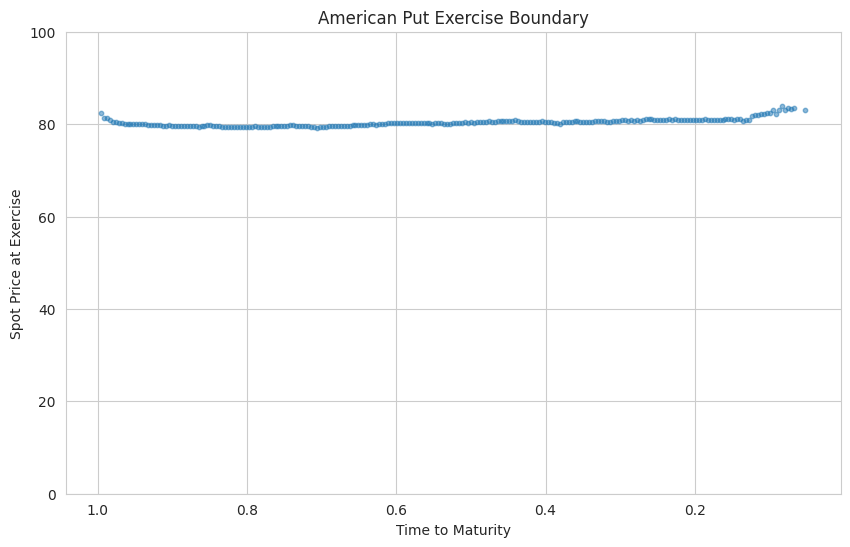

In [27]:
def exercise_boundary(S_paths, K, r, dt, option_type):
    n_paths, n_steps = S_paths.shape
    n_steps -= 1

    if option_type == 'put':
        payoffs = np.maximum(K - S_paths, 0)
    else:
        payoffs = np.maximum(S_paths - K, 0)

    cashflow = payoffs[:, -1].copy()
    boundary = []

    for t in range(n_steps - 1, 0, -1):
        itm = payoffs[:, t] > 0
        itm_indices = np.where(itm)[0]

        if len(itm_indices) > 10:
            X = S_paths[itm, t]
            Y = cashflow[itm] * np.exp(-r * dt)

            poly = np.polyfit(X, Y, 2)
            continuation = np.polyval(poly, X)

            exercise = payoffs[itm, t]
            exercise_decision = exercise > continuation

            cashflow[itm] = np.where(exercise_decision, exercise, cashflow[itm])

            exercise_indices = itm_indices[exercise_decision]
            if len(exercise_indices) > 0:
                boundary.append((t * dt, np.mean(S_paths[exercise_indices, t])))

    return boundary

print("Computing exercise boundary for American put...")
np.random.seed(42)
paths_boundary = generate_gbm_paths(S0, r, sigma, T, n_steps, 100000, seed=42)
boundary = exercise_boundary(paths_boundary, K, r, dt, 'put')

if boundary:
    times, prices = zip(*boundary)
    plt.figure(figsize=(10, 6))
    plt.scatter(times, prices, alpha=0.5, s=10)
    plt.xlabel('Time to Maturity')
    plt.ylabel('Spot Price at Exercise')
    plt.title('American Put Exercise Boundary')
    plt.ylim(0, K)
    plt.gca().invert_xaxis()
    plt.grid(True)
    plt.show()
else:
    print("No early exercise detected.")

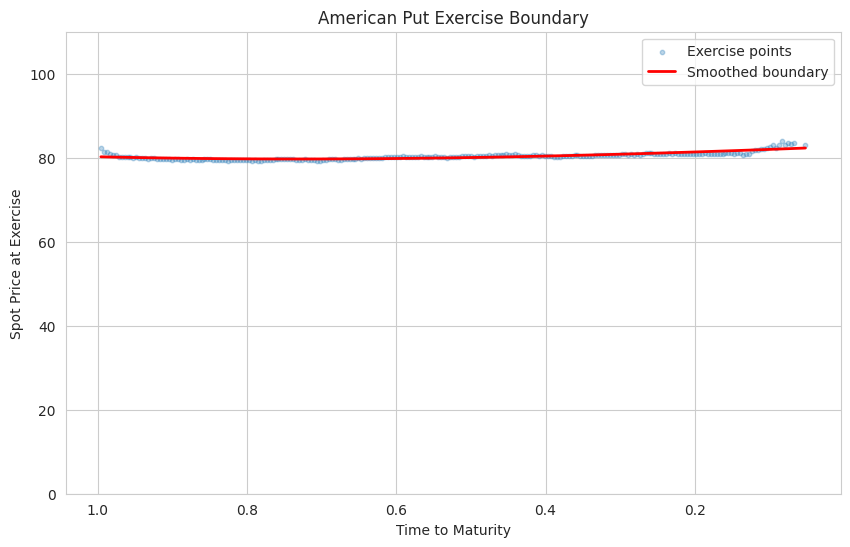

In [28]:
if boundary:
    times, prices = zip(*boundary)

    # Régression polynomiale pour lisser
    z = np.polyfit(times, prices, 3)
    p = np.poly1d(z)
    times_smooth = np.linspace(min(times), max(times), 100)
    prices_smooth = p(times_smooth)

    plt.figure(figsize=(10, 6))
    plt.scatter(times, prices, alpha=0.3, s=10, label='Exercise points')
    plt.plot(times_smooth, prices_smooth, 'r-', linewidth=2, label='Smoothed boundary')
    plt.xlabel('Time to Maturity')
    plt.ylabel('Spot Price at Exercise')
    plt.title('American Put Exercise Boundary')
    plt.ylim(0, K + 10)
    plt.gca().invert_xaxis()
    plt.legend()
    plt.grid(True)
    plt.show()

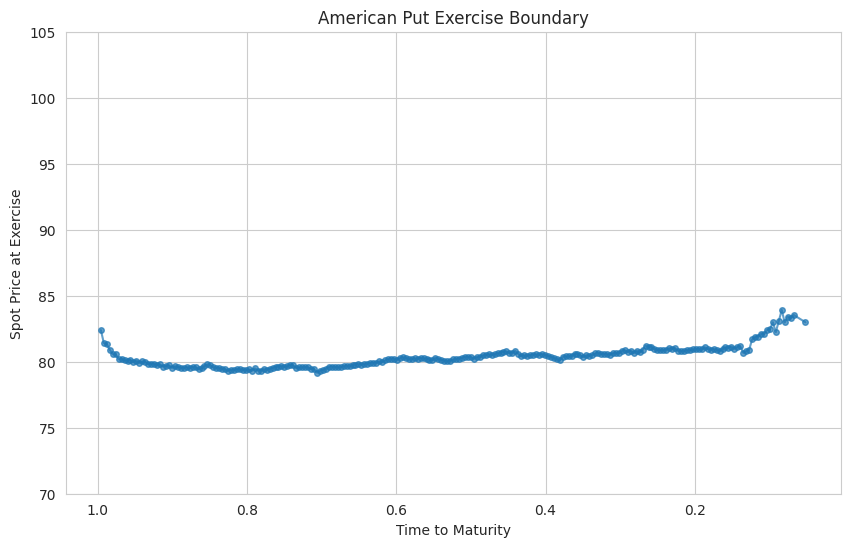

Min exercise price: 79.17
Max exercise price: 83.92
Range: 4.75


In [29]:
if boundary:
    times, prices = zip(*boundary)

    # Trier par temps
    sorted_idx = np.argsort(times)
    times_sorted = np.array(times)[sorted_idx]
    prices_sorted = np.array(prices)[sorted_idx]

    plt.figure(figsize=(10, 6))
    plt.plot(times_sorted, prices_sorted, 'o-', markersize=4, alpha=0.7)
    plt.xlabel('Time to Maturity')
    plt.ylabel('Spot Price at Exercise')
    plt.title('American Put Exercise Boundary')
    plt.ylim(70, K + 5)
    plt.gca().invert_xaxis()
    plt.grid(True)
    plt.show()

    print(f"Min exercise price: {min(prices):.2f}")
    print(f"Max exercise price: {max(prices):.2f}")
    print(f"Range: {max(prices) - min(prices):.2f}")

In [ ]:
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5]
premiums = []

for sig in sigmas:
    paths_sig = generate_gbm_paths(S0, r, sig, T, n_steps, n_paths, seed=42)
    american = price_american_mc(paths_sig, K, r, dt, 'put')
    european = BlackScholes(S0, K, T, r, sig).price('put')
    premiums.append(american - european)

plt.figure(figsize=(10, 6))
plt.plot(sigmas, premiums, 'o-')
plt.xlabel('Volatility')
plt.ylabel('Early Exercise Premium')
plt.title('Early Exercise Premium vs Volatility')
plt.grid(True)
plt.show()

In [ ]:
strikes = np.arange(80, 121, 5)
premiums_strike = []

for strike in strikes:
    paths_strike = generate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=42)
    american = price_american_mc(paths_strike, strike, r, dt, 'put')
    european = BlackScholes(S0, strike, T, r, sigma).price('put')
    premiums_strike.append(american - european)

plt.figure(figsize=(10, 6))
plt.plot(strikes, premiums_strike, 'o-')
plt.xlabel('Strike Price')
plt.ylabel('Early Exercise Premium')
plt.title('Early Exercise Premium vs Strike')
plt.grid(True)
plt.show()

In [ ]:
print("\nStrike analysis:")
print(f"{'Strike':<8} {'Euro Put':<12} {'US Put':<12} {'Premium':<12} {'Ratio Premium/Price':<20}")
print("-"*65)

for strike, premium in zip(strikes, premiums_strike):
    euro = BlackScholes(S0, strike, T, r, sigma).price('put')
    us = euro + premium
    ratio = premium / euro if euro > 0 else 0
    print(f"{strike:<8} {euro:<12.4f} {us:<12.4f} {premium:<12.4f} {ratio:<20.4f}")

In [ ]:
n_paths_list = [1000, 5000, 10000, 25000, 50000, 100000]
american_prices = []
european_ref = BlackScholes(S0, K, T, r, sigma).price('put')

for n in n_paths_list:
    paths_n = generate_gbm_paths(S0, r, sigma, T, n_steps, n, seed=42)
    american = price_american_mc(paths_n, K, r, dt, 'put')
    american_prices.append(american)
    print(f"{n:7d} paths: {american:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_paths_list, american_prices, 'o-', label='LSM American Put')
plt.axhline(y=european_ref, color='r', linestyle='--', label='European Put (ref)')
plt.xscale('log')
plt.xlabel('Number of Paths')
plt.ylabel('Option Price')
plt.title('Convergence of Longstaff-Schwartz Algorithm')
plt.legend()
plt.grid(True)
plt.show()